In [99]:
# Importation des packages et bibliothèques nécessaires pour l'analyse de données, le machine learning et la visualisation.

# Importations de la bibliothèque standard (fonctions intégrées de Python)
import os
import shap

# Importations de bibliothèques tierces (installées séparément)
import joblib  # Pour la sérialisation/désérialisation d'objets Python (par exemple, des modèles entraînés)
import kagglehub  # Pour télécharger des datasets depuis Kaggle
import matplotlib.pyplot as plt  # Pour la création de visualisations statiques, interactives et animées
import pandas as pd  # Pour la manipulation et l'analyse de données (structures de données comme les DataFrames)
import numpy as np
import seaborn as sns  # Pour la création de visualisations statistiques attrayantes et informatives
import statsmodels.api as sm  # Pour l'exploration de modèles statistiques et les tests statistiques
import random  # Pour la génération de nombres aléatoires (utilisé ici pour fixer la graine)

# Importations de Scikit-learn (bibliothèque de machine learning)
from sklearn.compose import ColumnTransformer  # Pour appliquer différentes transformations à différentes colonnes
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor  # Modèles d'ensemble pour la régression
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge  # Modèles de régression linéaire
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score, root_mean_squared_error  # Métriques d'évaluation des modèles de régression
from sklearn.model_selection import GridSearchCV, train_test_split  # Pour l'optimisation des hyperparamètres et la division des données
from sklearn.neighbors import KNeighborsRegressor  # Modèle de régression des k plus proches voisins
from sklearn.pipeline import Pipeline  # Pour créer un flux de travail (pipeline) de traitement de données et de modélisation
from sklearn.preprocessing import MaxAbsScaler, MinMaxScaler, OneHotEncoder, RobustScaler, StandardScaler  # Scalers et encodeurs pour le prétraitement des données
from sklearn.svm import SVR  # Régression des machines à vecteurs de support
from sklearn.tree import DecisionTreeRegressor  # Modèle d'arbre de décision pour la régression

# Autres importations de bibliothèques de machine learning
from xgboost import XGBRegressor  # Implémentation optimisée du Gradient Boosting (souvent très performante)

# Importations de Statsmodels et Scipy pour les tests statistiques
from scipy.stats import shapiro  # Test de normalité de Shapiro-Wilk
from statsmodels.stats.api import het_breuschpagan  # Test d'hétéroscédasticité de Breusch-Pagan
from statsmodels.stats.stattools import durbin_watson  # Test d'autocorrélation de Durbin-Watson

from copy import deepcopy  # Pour créer des copies indépendantes d'objets (utile pour les pipelines et préprocesseurs)


In [2]:
# Définit la graine (seed) pour le générateur de nombres aléatoires à 42.
# Cela assure la reproductibilité des résultats si des fonctions aléatoires sont utilisées ultérieurement.
random.seed(42)

print("Graine aléatoire globale définie à 42")

Graine aléatoire globale définie à 42


### **Importation**

In [3]:
# Télécharger le dataset depuis KaggleHub. La fonction retourne le chemin local du dossier.
path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Chemin du dossier :", path)

# Lister les fichiers présents dans le dossier téléchargé pour identifier le fichier CSV.
files = os.listdir(path)
print("Fichiers disponibles :", files)

# Construire le chemin complet vers le fichier CSV et le charger dans un DataFrame pandas.
csv_path = os.path.join(path, "insurance.csv")
data = pd.read_csv(csv_path)

# Afficher les 10 premières lignes du DataFrame pour un aperçu des données.
display(data.head(10))

Using Colab cache for faster access to the 'insurance' dataset.
Chemin du dossier : /kaggle/input/insurance
Fichiers disponibles : ['insurance.csv']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


### **Preprocessing**

#### **Suppression des doublons**

In [4]:
# Dimension avant suppression
print(f"Dimensions du dataset avant suppression des doublons : {data.shape}")

# Supprime les lignes dupliquées du DataFrame en place (modifie le DataFrame original).
# `inplace=True` signifie que la modification est appliquée directement au DataFrame `data`.
data.drop_duplicates(inplace=True)

# Dimension apres suppression
print(f"Dimensions du dataset après suppression des doublons : {data.shape}")

Dimensions du dataset avant suppression des doublons : (1338, 7)
Dimensions du dataset après suppression des doublons : (1337, 7)


#### **Transformation logarithmique de la variable cible**

In [5]:
# Applique une transformation logarithmique à la variable cible 'charges'
# np.log1p est utilisé car il gère mieux les valeurs nulles que np.log()
data['charges'] = np.log1p(data['charges'])


#### ***Création de la variable `is_obese`***

In [6]:
# Crée une nouvelle colonne 'is_obese' dans le DataFrame 'data'.
# La valeur est 'yes' si l'IMC (bmi) est supérieur ou égal à 30 (seuil médical d'obésité),
# et 'no' sinon. np.where est utilisé pour assigner les chaînes de caractères 'yes'/'no'.
data['is_obese'] = np.where(data['bmi'] >= 30, 'yes', 'no')


In [7]:
# Affiche les 5 premières lignes du DataFrame pour vérifier la nouvelle colonne.
display(data.head())

,age,sex,bmi,children,smoker,region,charges,is_obese
0,19,female,27.900,0,yes,southwest,9.734236,no
1,18,male,33.770,1,no,southeast,7.453882,yes
2,28,male,33.000,3,no,southeast,8.400763,yes
3,33,male,22.705,0,no,northwest,9.998137,no
4,32,male,28.880,0,no,northwest,8.260455,no


### **Processing**

Ici, nous séparons les variables catégorielles des variables quantitative continue.

L'idée est de pouvoir appliquer le traitement de façon séparé : `Mise en echelle pour les variables age et bmi` et `encoding pour les variables sex, smoker, region et is_obese`

In [8]:
# Définition des groupes de colonnes
num_features = ['age', 'bmi', 'children']
cat_features = ['sex', 'smoker', 'region','is_obese']

In [9]:
# Pipeline pour les caractéristiques numériques : Contient un placeholder pour le scaler.
# Le 'passthrough' indique qu'aucune transformation n'est appliquée par défaut à cette étape, elle sera définie ultérieurement.
num_transformer = Pipeline(steps=[
    ('scaler', 'passthrough')
])

# Pipeline pour les caractéristiques catégorielles : Applique un encodage One-Hot.
# 'drop='first'' est utilisé pour éviter la multicolinéarité (piège des variables muettes).
# 'handle_unknown='ignore'' permet de gérer les catégories inconnues lors de la prédiction sans erreur.
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])


# Assemblage du Preprocessor global avec ColumnTransformer.
# Il applique le 'num_transformer' aux 'num_features' et le 'cat_transformer' aux 'cat_features'.
preprocessor_template = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features), # Applique les transformations numériques aux colonnes numériques
        ('cat', cat_transformer, cat_features)   # Applique les transformations catégorielles aux colonnes catégorielles
    ])

### **Séparation des données**

In [10]:
## Séparation en variables explicatives et variable cible
X = data.drop('charges', axis=1)
y = data['charges']

## Séparation en donnée d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


### **Modélisation**

#### ***Définition des scalers***

In [11]:
# On définit les scalers à tester pour les modèles sensibles.

scalers = {
        'None': 'passthrough', #indique qu'aucun scaling ne sera appliqué pour cette option.
        'Standard': StandardScaler(), # Centre les données à la moyenne 0 et les met à l'échelle à l'écart type 1.
        'MinMax': MinMaxScaler(), # Met les données à l'échelle dans une plage donnée (par défaut entre 0 et 1).
        'Robust': RobustScaler(), # Met les données à l'échelle en utilisant des statistiques robustes aux outliers (médiane et IQR).
        'MaxAbs': MaxAbsScaler() # Met les données à l'échelle par leur valeur absolue maximale.
    }

#### ***Définition des modèles***

In [12]:
# --- GROUPE 1 : MODÈLES NON-ENSEMBLISTES (Simple/Baseline) ---
non_ensemble_scaling = {
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'ElasticNet': ElasticNet(),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR()
}

non_ensemble_no_scaling = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor()
}

# --- GROUPE 2 : MODÈLES ENSEMBLISTES  ---
ensemble_models = {
    'RandomForest': RandomForestRegressor(),
    'GradientBoost': GradientBoostingRegressor(),
    'XGBoost': XGBRegressor()
}

#### ***Définition des fonctions***

In [14]:
# Fonction qui entraînera tous les modèles et affichera les métriques
def evaluate_pipeline(X_train, X_test, y_train, y_test, preprocessor, model_name, model_obj, scaler_name,encoder_name):
    """Fonction utilitaire pour entraîner un modèle et calculer ses métriques de performance.

    Args:
        X_train (pd.DataFrame): Caractéristiques d'entraînement.
        X_test (pd.DataFrame): Caractéristiques de test.
        y_train (pd.Series): Cible d'entraînement.
        y_test (pd.Series): Cible de test.
        preprocessor (ColumnTransformer ou Pipeline): Le préprocesseur à appliquer aux données.
        model_name (str): Nom du modèle.
        model_obj (Estimator): L'objet modèle (régresseur) à entraîner.
        scaler_name (str): Nom du scaler utilisé.
        encoder_name (str): Nom de l'encodeur utilisé.

    Returns:
        dict: Un dictionnaire contenant les métriques de performance du modèle.
    """
    # Création d'un pipeline combinant le préprocesseur et le modèle
    pipe = Pipeline(steps=[('prepro', preprocessor), ('reg', model_obj)])

    # Entraînement du pipeline sur les données d'entraînement
    pipe.fit(X_train, y_train)

    # Prédiction sur les ensembles d'entraînement et de test
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    # Calcul des différentes métriques de performance
    res = {
        'Model': model_name,
        'Scaler': scaler_name,
        'Encoder': encoder_name,
        'MAE_Train': mean_absolute_error(y_train, y_train_pred),
        'MAE_Test': mean_absolute_error(y_test, y_test_pred),
        'MSE_Train': mean_squared_error(y_train, y_train_pred),
        'MSE_Test': mean_squared_error(y_test, y_test_pred),
        'RMSE_Train': root_mean_squared_error(y_train, y_train_pred),
        'RMSE_Test': root_mean_squared_error(y_test, y_test_pred),
        'MAPE_Train': mean_absolute_percentage_error(y_train, y_train_pred),
        'MAPE_Test': mean_absolute_percentage_error(y_test, y_test_pred),
        'R2_Train': r2_score(y_train, y_train_pred),
        'R2_Test': r2_score(y_test, y_test_pred)
    }
    # Calcul de la différence absolue R2 entre l'entraînement et le test pour évaluer l'overfitting
    res['Overfit_Diff'] = abs(res['R2_Train'] - res['R2_Test'])
    return res

In [15]:

def train_multiple_models(X_train, X_test, y_train, y_test, scalers, models_dict, preprocessor_template, force_scaling=True, linear_model=True, force_encoding="drop"):
    results = []

    # 1. COPIE LOCALE des DataFrames pour éviter de modifier les données globales
    # et permettre de relancer la fonction sans erreur.
    X_train_local = X_train.copy()
    X_test_local = X_test.copy()

    # Crée une nouvelle copie du modèle de préprocesseur pour chaque exécution afin d'éviter les interférences
    preprocessor = deepcopy(preprocessor_template)

    # 2. GESTION DE LA VARIABLE POUR MODÈLES LINÉAIRES
    # Si 'linear_model' est True, cela signifie que nous traitons des modèles linéaires
    if linear_model:
        # Nom de la colonne à potentiellement supprimer (souvent pour éviter la multicolinéarité avec les dummies)
        col_to_drop = 'is_obese'

        # Suppression sécurisée de la colonne dans les DataFrames locaux si elle existe
        if col_to_drop in X_train_local.columns:
            X_train_local = X_train_local.drop(col_to_drop, axis=1)
            X_test_local = X_test_local.drop(col_to_drop, axis=1)

        # --- MISE À JOUR DU PREPROCESSOR ---
        # Le préprocesseur doit être informé de la colonne supprimée.
        # On vérifie dans les colonnes numériques (index 0) ET catégorielles (index 1)
        # pour être sûr de ne rien rater.
        for i in [0, 1]:
            # Récupère la liste actuelle des colonnes gérées par ce transformateur
            current_cols = list(preprocessor.transformers[i][2])
            if col_to_drop in current_cols:
                # Si la colonne est trouvée, on la retire de la liste
                current_cols.remove(col_to_drop)
                # On met à jour le tuple du transformer 'i' avec la nouvelle liste de colonnes
                preprocessor.transformers[i] = (
                    preprocessor.transformers[i][0],
                    preprocessor.transformers[i][1],
                    current_cols
                )

    # --- Configuration de l'encodage ---
    # Index 1 correspond au transformateur catégoriel dans le ColumnTransformer
    if force_encoding == "None":
        # Si 'None', on désactive l'encodage pour cette étape
        preprocessor.transformers[1][1].steps[0] = ('onehot', 'passthrough')
        encoder_name = 'No Encoding'
    elif force_encoding == "all":
        # Si 'all', on utilise OneHotEncoder en gardant toutes les colonnes (pas de 'drop=first')
        preprocessor.transformers[1][1].steps[0] = ('onehot', OneHotEncoder(handle_unknown='ignore'))
        encoder_name = 'OneHot Encoding with All'
    else:
        # Par défaut, on utilise OneHotEncoder avec 'drop=first' (pour éviter la multicolinéarité)
        encoder_name = 'OneHot Encoding with Drop'

    # --- Configuration de la mise à l'échelle et exécution des modèles ---
    # Index 0 correspond au transformateur numérique dans le ColumnTransformer
    if force_scaling:
        # Si la mise à l'échelle est forcée, on itère sur tous les scalers définis
        for scaler_name, scaler_obj in scalers.items():
            # On configure le scaler pour le transformateur numérique
            preprocessor.transformers[0][1].steps[0] = ('scaler', scaler_obj)
            # Nom du scaler pour les résultats
            scal_name = scaler_name if scaler_name != 'None' else 'No Scaling'

            # On itère sur chaque modèle à évaluer
            for model_name, model_obj in models_dict.items():
                # UTILISATION DES DATAFRAMES LOCAUX pour l'évaluation
                results.append(evaluate_pipeline(X_train_local, X_test_local, y_train, y_test, preprocessor, model_name, model_obj, scal_name, encoder_name))
    else:
        # Si la mise à l'échelle n'est pas forcée, on utilise 'passthrough' (pas de scaling)
        preprocessor.transformers[0][1].steps[0] = ('scaler', 'passthrough')
        scal_name = 'No Scaling'
        # On itère sur chaque modèle à évaluer
        for model_name, model_obj in models_dict.items():
            # UTILISATION DES DATAFRAMES LOCAUX pour l'évaluation
            results.append(evaluate_pipeline(X_train_local, X_test_local, y_train, y_test, preprocessor, model_name, model_obj, scal_name, encoder_name))

    # Retourne les résultats sous forme de DataFrame pandas
    return pd.DataFrame(results)

In [16]:
###Afficher le tableau mieux styliser
def style_results(df):
    # Fonction interne pour mettre en évidence les problèmes d'overfitting
    def highlight_issues(row):
        # Si l'écart absolu de R2 entre l'entraînement et le test est supérieur à 0.1,
        # cela suggère un overfitting, et la ligne est mise en évidence en rouge clair.
        color = 'background-color: #ffcccc' if row['Overfit_Diff'] > 0.1 else ''
        return [color] * len(row)

    # Applique la fonction 'highlight_issues' pour colorer les lignes où l'overfitting est détecté.
    # Met en évidence la valeur minimale dans les colonnes de métriques d'erreur de test (MAE, MSE, RMSE, MAPE) en vert clair.
    # Met en évidence la valeur maximale dans la colonne R2 de test en vert clair.
    # Formate toutes les valeurs numériques à deux décimales.
    styled = df.style.apply(highlight_issues, axis=1) \
        .highlight_min(subset=['MAE_Test'], color='lightgreen') \
        .highlight_min(subset=['MSE_Test'], color='lightgreen') \
        .highlight_min(subset=['RMSE_Test'], color='lightgreen') \
        .highlight_min(subset=['MAPE_Test'], color='lightgreen') \
        .highlight_max(subset=['R2_Test'], color='lightgreen') \
        .format(precision=2)

    return styled

#### ***Application des fonctions***

In [17]:
# Modèles Non-Ensemblistes ---
print("Entraînement des modèles Non-Ensemblistes...")
# Concatène les résultats de l'entraînement des modèles non-ensemblistes.
res_non_ensemble = pd.concat([

    # Le premier  concerne les modèles sensibles au scaling.
    train_multiple_models(X_train, X_test, y_train, y_test, scalers, non_ensemble_scaling, preprocessor_template, force_scaling=True),

    # Le second concerne les modèles non sensibles au scaling (comme LinearRegression ou DecisionTree).
    train_multiple_models(X_train, X_test, y_train, y_test, scalers, non_ensemble_no_scaling, preprocessor_template, force_scaling=False,linear_model=True)
])

Entraînement des modèles Non-Ensemblistes...


In [18]:
# Modèles Ensemblistes ---
print("Entraînement des modèles Ensemblistes...")
# Pour les arbres/ensembles, on force le passthrough car le scaling n'apporte rien

res_ensemble = pd.concat([
    train_multiple_models(X_train, X_test, y_train, y_test, scalers, ensemble_models, preprocessor_template, force_scaling=False,linear_model=False,force_encoding="drop"),
    train_multiple_models(X_train, X_test, y_train, y_test, scalers, ensemble_models, preprocessor_template, force_scaling=False,linear_model=False,force_encoding="all")
])

Entraînement des modèles Ensemblistes...


In [19]:
combined_results = pd.concat([res_non_ensemble, res_ensemble], ignore_index=True)
style_results(combined_results)

,Model,Scaler,Encoder,MAE_Train,MAE_Test,MSE_Train,MSE_Test,RMSE_Train,RMSE_Test,MAPE_Train,MAPE_Test,R2_Train,R2_Test,Overfit_Diff
0,Lasso,No Scaling,OneHot Encoding with Drop,0.64,0.60,0.62,0.58,0.79,0.76,0.07,0.07,0.29,0.22,0.07
1,Ridge,No Scaling,OneHot Encoding with Drop,0.28,0.27,0.20,0.19,0.45,0.44,0.03,0.03,0.77,0.74,0.03
2,ElasticNet,No Scaling,OneHot Encoding with Drop,0.64,0.60,0.62,0.58,0.79,0.76,0.07,0.07,0.30,0.22,0.08
3,KNN,No Scaling,OneHot Encoding with Drop,0.46,0.53,0.40,0.58,0.63,0.76,0.05,0.06,0.54,0.23,0.31
4,SVR,No Scaling,OneHot Encoding with Drop,0.47,0.44,0.64,0.63,0.80,0.80,0.05,0.05,0.28,0.15,0.13
5,Lasso,Standard,OneHot Encoding with Drop,0.76,0.70,0.88,0.75,0.94,0.87,0.09,0.08,0.00,-0.00,0.00
6,Ridge,Standard,OneHot Encoding with Drop,0.28,0.27,0.20,0.19,0.45,0.44,0.03,0.03,0.77,0.74,0.03
7,ElasticNet,Standard,OneHot Encoding with Drop,0.76,0.69,0.87,0.74,0.93,0.86,0.09,0.08,0.01,0.01,0.00
8,KNN,Standard,OneHot Encoding with Drop,0.25,0.32,0.16,0.24,0.40,0.49,0.03,0.03,0.82,0.67,0.14
9,SVR,Standard,OneHot Encoding with Drop,0.17,0.18,0.14,0.14,0.37,0.37,0.02,0.02,0.84,0.82,0.03


**Conclusion partielle**

#### **Détail sur le modele de regression linéaire**

##### ***Entrainement et prédiction***

In [81]:

#Construction de la pipeline
Regression_lineaire = Pipeline(steps=[
    ('prepro', preprocessor_template),
    ('reg', LinearRegression())
])


# Entrainement
Regression_lineaire.fit(X_train, y_train)


Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   'passthrough')]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['sex', 'smoker', 'region',
                                                   'is_obese'])])),
                ('reg', LinearRegression())])

In [42]:
y_pred_lr = Regression_lineaire.predict(X_test)
residuals_lr = y_test - y_pred_lr


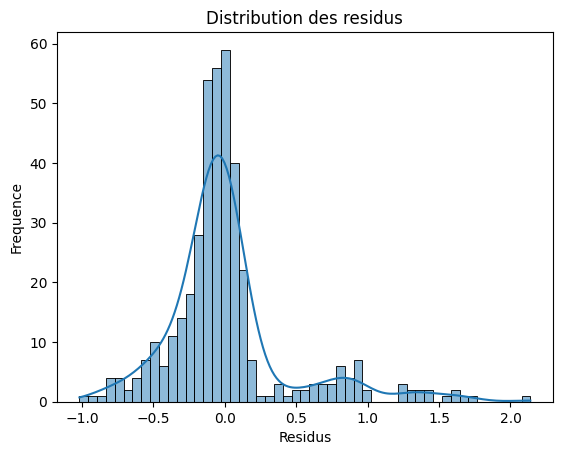

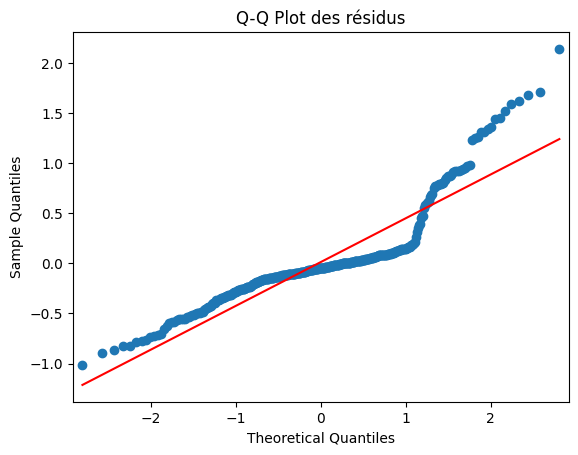

In [43]:
# Plotting the histogram of residuals
sns.histplot(residuals_lr, kde=True)
plt.title('Distribution des residus')
plt.xlabel('Residus')
plt.ylabel('Frequence')

# Plotting the Q-Q plot of residuals
sm.qqplot(residuals_lr, line='s')
plt.title('Q-Q Plot des résidus')
plt.show()

##### **Normalité des résidus**

In [44]:


# Perform Shapiro-Wilk test on the residuals
shapiro_test_statistic, shapiro_p_value = shapiro(residuals_lr)

print(f"Shapiro-Wilk Test Statistic: {shapiro_test_statistic:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p_value:.4f}")

# Interpret the p-value
alpha = 0.05
if shapiro_p_value < alpha:
    print("Conclusion: Les résidus ne semble pas suivre une distribution normale (rejet H0).")
else:
    print("Conclusion: Les résidus semble suivre une distribution normale (non rejet de H0).")

Shapiro-Wilk Test Statistic: 0.8297
Shapiro-Wilk p-value: 0.0000
Conclusion: Les résidus ne semble pas suivre une distribution normale (rejet H0).


##### Homoscédasticité

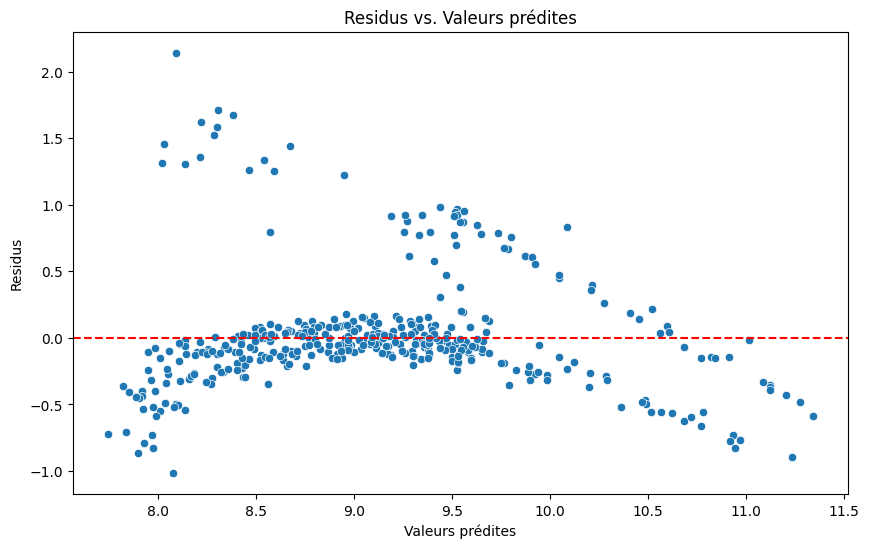

In [45]:


# Create a scatter plot of residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_lr, y=residuals_lr)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.xlabel('Valeurs prédites')
plt.ylabel('Residus')
plt.title('Residus vs. Valeurs prédites')
plt.show()

In [46]:

# 4. Apply the preprocessor to X_test
X_test_preprocessed = preprocessor_template.transform(X_test)

# 5. Add a constant term to the preprocessed X_test data
X_test_preprocessed_with_const = sm.add_constant(X_test_preprocessed)

# 6. Perform the Breusch-Pagan test
bp_test = het_breuschpagan(residuals_lr, X_test_preprocessed_with_const)

# Store the results in a dictionary for easy access and printing
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
bp_results = dict(zip(labels, bp_test))

# 7. Print the results of the Breusch-Pagan test
print("Breusch-Pagan Test Results:")
for label, value in bp_results.items():
    print(f"{label}: {value:.4f}")

# 8. Interpret the p-value (F-Test p-value)
alpha = 0.05
if bp_results['F-Test p-value'] < alpha:
    print(f"\nConclusion: F-Test p-value ({bp_results['F-Test p-value']:.4f}) < alpha ({alpha}), donc nous rejetons H0.\nIl existe suffisamment de preuves pour conclure à la présence d'hétéroscédasticité.")
else:
    print(f"\nConclusion: F-Test p-value ({bp_results['F-Test p-value']:.4f}) >= alpha ({alpha}), donc nous rejetons H0.\nIl n'existe pas suffisamment de preuves pour conclure à la présence d'hétéroscédasticité.")

Breusch-Pagan Test Results:
LM Statistic: 29.8184
LM-Test p-value: 0.0005
F-Statistic: 3.4896
F-Test p-value: 0.0004

Conclusion: F-Test p-value (0.0004) < alpha (0.05), donc nous rejetons H0.
Il existe suffisamment de preuves pour conclure à la présence d'hétéroscédasticité.


##### ***Indépendance des résidus***

In [47]:

# Perform the Durbin-Watson test on the residuals
dw_test = durbin_watson(residuals_lr)

# Print the Durbin-Watson test statistic
print(f"Durbin-Watson test statistic: {dw_test:.4f}")

# Interpret the Durbin-Watson statistic
if dw_test < 1.5 or dw_test > 2.5:
    print("Conclusion: The residuals exhibit evidence of autocorrelation (not independent).")
else:
    print("Conclusion: The residuals appear to be independent (no significant autocorrelation).")

Durbin-Watson test statistic: 2.0896
Conclusion: The residuals appear to be independent (no significant autocorrelation).


### **Optimisation des hyperparamètres**

#### ***Liste des modèles avec les hyperparamètres***

In [50]:
# --- GROUPE 1 : MODÈLES NON-ENSEMBLISTES (Simple/Baseline) ---
# Cette section définit les modèles de régression non-ensemblistes qui seront testés, avec leurs hyperparamètres à optimiser.
# Chaque entrée est un tuple (instance du modèle, dictionnaire des hyperparamètres à tester).

# Modèles non-ensemblistes sensibles au scaling (ces modèles bénéficient généralement d'une mise à l'échelle des données).
non_ensemble_scaling = {
    'Lasso': (Lasso(max_iter=10000), {
            'reg__alpha': [0.001, 0.01, 0.1, 1.0] # Paramètre de régularisation L1 (force la parcimonie).
        }),
        'Ridge': (Ridge(), {
            'reg__alpha': [0.001, 0.01, 0.1, 1.0] # Paramètre de régularisation L2 (réduit l'impact des coefficients).
        }),
        'ElasticNet': (ElasticNet(), {
            'reg__alpha': [0.001, 0.01, 0.1, 1.0], # Paramètre de régularisation global.
            'reg__l1_ratio': [0.0, 0.1, 0.5, 0.9] # Rapport de mélange entre L1 et L2 (0 pour Ridge, 1 pour Lasso).
        }),
        'KNN': (KNeighborsRegressor(), {
            'reg__n_neighbors': [3, 5, 7, 9], # Nombre de voisins à considérer.
            'reg__weights': ['uniform', 'distance'] # Pondération des voisins (uniforme ou par distance).
        }),
        'SVR': (SVR(), {
            'reg__C': [0.1, 1, 10, 100], # Paramètre de régularisation (pénalité pour les erreurs).
            'reg__epsilon': [0.1, 0.2, 0.5, 1.0], # Marge d'insensibilité (erreurs tolérées).
            'reg__kernel': ['rbf'] # Type de fonction noyau (radial basis function).
        })
}

# Modèles non-ensemblistes moins sensibles au scaling (ou qui ne le nécessitent pas).
non_ensemble_no_scaling = {
    'LinearRegression': (LinearRegression(), {
            'reg__fit_intercept': [True, False] # Calculer ou non l'ordonnée à l'origine.
        }),

        'DecisionTree': (DecisionTreeRegressor(), {
            'reg__max_depth': [None, 5, 10, 15], # Profondeur maximale de l'arbre.
            'reg__min_samples_split': [2, 5, 10, 20] # Nombre minimum d'échantillons requis pour diviser un nœud.
        }),
}

# --- GROUPE 2 : MODÈLES ENSEMBLISTES (Puissance) ---
# Cette section définit les modèles de régression ensemblistes, réputés pour leur performance, avec leurs hyperparamètres à optimiser.
ensemble_models = {
    'RandomForest': (RandomForestRegressor(), {
            'reg__n_estimators': [50, 100, 200, 300], # Nombre d'arbres dans la forêt.
            'reg__max_depth': [None, 10, 20, 30], # Profondeur maximale des arbres individuels.
            'reg__min_samples_split': [2, 5, 10, 20] # Nombre minimum d'échantillons pour diviser un nœud.
        }),
        'XGBoost': (XGBRegressor(), {
            'reg__n_estimators': [50, 100, 200, 300], # Nombre d'arbres de boosting.
            'reg__learning_rate': [0.01, 0.05, 0.1, 0.2], # Taux d'apprentissage.
            'reg__max_depth': [3, 6, 9, 12] # Profondeur maximale des arbres.
        }),
        'GradientBoost': (GradientBoostingRegressor(), {
            'reg__n_estimators': [50, 100, 200, 300], # Nombre d'étapes de boosting.
            'reg__learning_rate': [0.01, 0.05, 0.1, 0.2], # Taux d'apprentissage.
            'reg__subsample': [0.6, 0.8, 0.9, 1.0] # Fraction des échantillons à utiliser pour ajuster les estimateurs individuels.
        })
}

#### ***Encodage***  

In [51]:
# Définir les différentes stratégies d'encodage

encoder_non_assembliste = {
    'OneHot_DropFirst': OneHotEncoder(handle_unknown='ignore', drop='first'),

}

encoder_assembliste = {
    'OneHot_DropFirst': OneHotEncoder(handle_unknown='ignore', drop='first'),
    'OneHot_KeepAll': OneHotEncoder(handle_unknown='ignore')
}

#### ***Définition des fonctions***

In [52]:
def optimize_hyperparameters(X_train, y_train, X_test, y_test, num_features, cat_features, models_to_tune, scalers, encoder_configs, metric_score, linear_model=True):
    all_tuned_results = []
    best_estimators_per_config = {}

    # --- ÉTAPE 1 : COPIE LOCALE ---
    # On crée des copies pour ne pas modifier les listes et DataFrames originaux
    X_train_local = X_train.copy()
    X_test_local = X_test.copy()
    curr_num_features = list(num_features) if num_features else []
    curr_cat_features = list(cat_features) if cat_features else []

    # --- ÉTAPE 2 : SUPPRESSION SÉCURISÉE ---
    if linear_model:
        col_to_drop = 'is_obese'

        # Supprimer des DataFrames (seulement si présent)
        if col_to_drop in X_train_local.columns:
            X_train_local = X_train_local.drop(col_to_drop, axis=1)
            X_test_local = X_test_local.drop(col_to_drop, axis=1)

        # Supprimer de la liste locale (sans réassigner, et seulement si présent)
        if col_to_drop in curr_cat_features:
            curr_cat_features.remove(col_to_drop)
        elif col_to_drop in curr_num_features:
            curr_num_features.remove(col_to_drop)

    # Normalisation des scalers
    scalers_dict = scalers if (scalers != 'None' and scalers is not None) else {'No_Scaling': 'passthrough'}

    for scaler_name, scaler_obj in scalers_dict.items():
        for encoder_name, encoder_obj in encoder_configs.items():
            print(f"--- Tuning with Scaler: {scaler_name}, Encoder: {encoder_name} ---")

            # 1. Préparation du Numerical Transformer
            num_transformer = 'passthrough' if scaler_obj == 'passthrough' else Pipeline(steps=[('scaler', scaler_obj)])

            # 2. Préparation du Categorical Transformer
            cat_transformer = 'passthrough' if encoder_obj == 'passthrough' else Pipeline(steps=[('onehot', encoder_obj)])

            # 3. Construction du ColumnTransformer avec les listes LOCALES
            transformers_list = []
            if curr_num_features:
                transformers_list.append(('num', num_transformer, curr_num_features))
            if curr_cat_features:
                transformers_list.append(('cat', cat_transformer, curr_cat_features))

            current_preprocessor = ColumnTransformer(transformers_list) if transformers_list else 'passthrough'

            # 4. Boucle sur les modèles
            for name, (model, params) in models_to_tune.items():
                print(f"Optimisation de {name}...")

                pipe = Pipeline(steps=[('prepro', current_preprocessor), ('reg', model)]) if current_preprocessor != 'passthrough' else Pipeline(steps=[('reg', model)])

                # On utilise les données LOCALES
                grid = GridSearchCV(pipe, params, cv=5, scoring=metric_score, n_jobs=-1)
                grid.fit(X_train_local, y_train)

                config_key = f"{name}_{scaler_name}_{encoder_name}"
                best_model = grid.best_estimator_
                best_estimators_per_config[config_key] = best_model

                # Prédictions sur les données LOCALES
                y_train_pred = best_model.predict(X_train_local)
                y_test_pred = best_model.predict(X_test_local)

                r2_tr, r2_te = r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred)

                res = {
                    'Model': name,
                    'Scaler': scaler_name,
                    'Encoder': encoder_name,
                    'Best_RMSE_CV': -grid.best_score_ if 'neg_' in metric_score else grid.best_score_,
                    'MAE_Train': mean_absolute_error(y_train, y_train_pred),
                    'MAE_Test': mean_absolute_error(y_test, y_test_pred),
                    'MSE_Train': mean_squared_error(y_train, y_train_pred),
                    'MSE_Test': mean_squared_error(y_test, y_test_pred),
                    'RMSE_Train': root_mean_squared_error(y_train, y_train_pred),
                    'RMSE_Test': root_mean_squared_error(y_test, y_test_pred),
                    'MAPE_Train': mean_absolute_percentage_error(y_train, y_train_pred),
                    'MAPE_Test': mean_absolute_percentage_error(y_test, y_test_pred),
                    'R2_Train': r2_tr,
                    'R2_Test': r2_te,
                    'Overfit_Diff': abs(r2_tr - r2_te),
                    'Best_Params': str(grid.best_params_)
                }
                all_tuned_results.append(res)

    return pd.DataFrame(all_tuned_results), best_estimators_per_config

    return pd.DataFrame(all_tuned_results), best_estimators_per_config

#### ***Application des fonctions***

In [58]:
#Application aux modèles non ensemblistes sensible au scaling
df_tuning1, best_models_dict1 = optimize_hyperparameters(X_train, y_train, X_test, y_test, num_features, cat_features, non_ensemble_scaling, scalers, encoder_non_assembliste, 'neg_root_mean_squared_error',linear_model=True)

--- Tuning with Scaler: None, Encoder: OneHot_DropFirst ---
Optimisation de Lasso...
Optimisation de Ridge...
Optimisation de ElasticNet...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.407e+01, tolerance: 8.257e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Optimisation de KNN...
Optimisation de SVR...
--- Tuning with Scaler: Standard, Encoder: OneHot_DropFirst ---
Optimisation de Lasso...
Optimisation de Ridge...
Optimisation de ElasticNet...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.419e+01, tolerance: 8.257e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Optimisation de KNN...
Optimisation de SVR...
--- Tuning with Scaler: MinMax, Encoder: OneHot_DropFirst ---
Optimisation de Lasso...
Optimisation de Ridge...
Optimisation de ElasticNet...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.552e+01, tolerance: 8.257e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Optimisation de KNN...
Optimisation de SVR...
--- Tuning with Scaler: Robust, Encoder: OneHot_DropFirst ---
Optimisation de Lasso...
Optimisation de Ridge...
Optimisation de ElasticNet...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.442e+01, tolerance: 8.257e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Optimisation de KNN...
Optimisation de SVR...
--- Tuning with Scaler: MaxAbs, Encoder: OneHot_DropFirst ---
Optimisation de Lasso...
Optimisation de Ridge...
Optimisation de ElasticNet...
Optimisation de KNN...
Optimisation de SVR...


In [59]:
#Application aux modèles non ensemblistes non sensible au scaling
df_tuning2, best_models_dict2 = optimize_hyperparameters(X_train, y_train, X_test, y_test, num_features, cat_features, non_ensemble_no_scaling,'None', encoder_non_assembliste, 'neg_root_mean_squared_error',linear_model=True)


--- Tuning with Scaler: No_Scaling, Encoder: OneHot_DropFirst ---
Optimisation de LinearRegression...
Optimisation de DecisionTree...


In [60]:
#Application aux modèles ensemblistes
df_tuning3, best_models_dict3 = optimize_hyperparameters(X_train, y_train, X_test, y_test, num_features, cat_features, ensemble_models, 'None', encoder_assembliste, 'neg_root_mean_squared_error',linear_model=False)


--- Tuning with Scaler: No_Scaling, Encoder: OneHot_DropFirst ---
Optimisation de RandomForest...
Optimisation de XGBoost...
Optimisation de GradientBoost...
--- Tuning with Scaler: No_Scaling, Encoder: OneHot_KeepAll ---
Optimisation de RandomForest...
Optimisation de XGBoost...
Optimisation de GradientBoost...


In [62]:
#Concaténation des trois tables
results = pd.concat([df_tuning1, df_tuning2, df_tuning3],ignore_index=True)

# Affichage stylisé du resultat final
style_results(results)

,Model,Scaler,Encoder,Best_MAE_CV,MAE_Train,MAE_Test,MSE_Train,MSE_Test,RMSE_Train,RMSE_Test,MAPE_Train,MAPE_Test,R2_Train,R2_Test,Overfit_Diff,Best_Params
0,Lasso,None,OneHot_DropFirst,0.45,0.28,0.27,0.20,0.19,0.45,0.44,0.03,0.03,0.77,0.74,0.03,{'reg__alpha': 0.001}
1,Ridge,None,OneHot_DropFirst,0.45,0.28,0.27,0.20,0.19,0.45,0.44,0.03,0.03,0.77,0.74,0.03,{'reg__alpha': 0.1}
2,ElasticNet,None,OneHot_DropFirst,0.45,0.28,0.27,0.20,0.19,0.45,0.44,0.03,0.03,0.77,0.74,0.03,"{'reg__alpha': 0.001, 'reg__l1_ratio': 0.0}"
3,KNN,None,OneHot_DropFirst,0.78,0.00,0.54,0.00,0.54,0.05,0.74,0.00,0.06,1.00,0.28,0.72,"{'reg__n_neighbors': 9, 'reg__weights': 'distance'}"
4,SVR,None,OneHot_DropFirst,0.40,0.18,0.18,0.16,0.14,0.39,0.38,0.02,0.02,0.82,0.81,0.01,"{'reg__C': 100, 'reg__epsilon': 0.1, 'reg__kernel': 'rbf'}"
5,Lasso,Standard,OneHot_DropFirst,0.45,0.28,0.27,0.20,0.19,0.45,0.44,0.03,0.03,0.77,0.74,0.03,{'reg__alpha': 0.001}
6,Ridge,Standard,OneHot_DropFirst,0.45,0.28,0.27,0.20,0.19,0.45,0.44,0.03,0.03,0.77,0.74,0.03,{'reg__alpha': 0.1}
7,ElasticNet,Standard,OneHot_DropFirst,0.45,0.28,0.27,0.20,0.19,0.45,0.44,0.03,0.03,0.77,0.74,0.03,"{'reg__alpha': 0.001, 'reg__l1_ratio': 0.0}"
8,KNN,Standard,OneHot_DropFirst,0.51,0.00,0.30,0.00,0.24,0.05,0.49,0.00,0.03,1.00,0.68,0.32,"{'reg__n_neighbors': 5, 'reg__weights': 'distance'}"
9,SVR,Standard,OneHot_DropFirst,0.39,0.17,0.18,0.14,0.14,0.37,0.37,0.02,0.02,0.84,0.82,0.03,"{'reg__C': 1, 'reg__epsilon': 0.1, 'reg__kernel': 'rbf'}"


### **Choix du meilleur modèle**

#### ***Infos sur le meilleur modèle***

In [66]:
best_model_idx = results['MSE_Test'].idxmin()
best_model = results.loc[best_model_idx]
display(best_model)

,32
Model,GradientBoost
Scaler,No_Scaling
Encoder,OneHot_KeepAll
Best_MAE_CV,0.38113
MAE_Train,0.180937
MAE_Test,0.17772
MSE_Train,0.117815
MSE_Test,0.121714
RMSE_Train,0.343242
RMSE_Test,0.348875


In [67]:
# Nom et paramètres du meilleur modèle
best_model_name = model_key = f"{best_model['Model']}_{best_model['Scaler']}_{best_model['Encoder']}"
best_params = best_model['Best_Params']

print(f"Meilleur modèle: {best_model_name}")
print(f"Hyperparamètres optimaux: {best_params}")


Meilleur modèle: GradientBoost_No_Scaling_OneHot_KeepAll
Hyperparamètres optimaux: {'reg__learning_rate': 0.05, 'reg__n_estimators': 100, 'reg__subsample': 0.8}


In [68]:
## Concaténation des trois dictionnaires de best_models
best_models_dict = {**best_models_dict1, **best_models_dict2, **best_models_dict3}

In [69]:
#Pipeline du meilleur modèle
best_pipeline = best_models_dict[best_model_name]

print(f"Objet pipeline du meilleur modèle: {best_pipeline}")

Objet pipeline du meilleur modèle: Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker', 'region',
                                                   'is_obese'])])),
                ('reg',
                 GradientBoostingRegressor(learning_rate=0.05, subsample=0.8))])



#### ***Prediction***


In [83]:
##Prediction sur les données test
y_test_pred_final = best_pipeline.predict(X_test)

In [71]:
## Calcul
# Calcul de l'erreur absolue moyenne (Mean Absolute Error - MAE) sur l'ensemble de test
mae_test_final = mean_absolute_error(y_test, y_test_pred_final)
# Calcul de l'erreur quadratique moyenne (Mean Squared Error - MSE) sur l'ensemble de test
mse_test_final = mean_squared_error(y_test, y_test_pred_final)
# Calcul de la racine carrée de l'erreur quadratique moyenne (Root Mean Squared Error - RMSE) sur l'ensemble de test
rmse_test_final = root_mean_squared_error(y_test, y_test_pred_final)
# Calcul de l'erreur absolue moyenne en pourcentage (Mean Absolute Percentage Error - MAPE) sur l'ensemble de test
mape_test_final = mean_absolute_percentage_error(y_test, y_test_pred_final)
# Calcul du coefficient de détermination (R2 score) sur l'ensemble de test
r2_test_final = r2_score(y_test, y_test_pred_final)


print("Metrique sur les prédictions")
print(f"MAE: {mae_test_final:.2f}")
print(f"MSE: {mse_test_final:.2f}")
print(f"RMSE: {rmse_test_final:.2f}")
print(f"MAPE: {mape_test_final:.2f}")
print(f"R2: {r2_test_final:.2f}")

Metrique sur les prédictions
MAE: 0.18
MSE: 0.12
RMSE: 0.35
MAPE: 0.02
R2: 0.84


In [72]:
# Définition d'une classe Pipeline personnalisée qui applique np.expm1 aux prédictions
class Expm1PredictionPipeline(Pipeline):
    """
    Une sous-classe de Pipeline qui applique la transformation inverse (exponentielle - 1)
    aux prédictions finales du régresseur contenu dans le pipeline.
    """
    def predict(self, X, **predict_params):
        # 1. Appel de la méthode predict du parent (Pipeline) pour obtenir les prédictions en log
        log_predictions = super().predict(X, **predict_params)

        # 2. Application de la transformation inverse (np.expm1) pour revenir à l'échelle originale ($)
        # expm1(x) calcule exp(x) - 1, ce qui est l'inverse exact de log1p(x)
        return np.expm1(log_predictions)

# Récupération des étapes d'origine et de leurs "estimateurs déjà entraînés" (fitted estimators)
# C'est crucial car nous ne voulons pas ré-entraîner le modèle, mais juste changer son comportement.
original_fitted_steps = []
for name, estimator in best_pipeline.steps:
    # On récupère l'instance exacte de l'estimateur déjà ajusté via named_steps
    original_fitted_steps.append((name, best_pipeline.named_steps[name]))

# Recréation de la best_pipeline en tant qu'instance de notre classe personnalisée.
# Ce nouveau pipeline utilise les composants déjà entraînés du pipeline original,
# mais sa méthode .predict() inclura désormais automatiquement la transformation np.expm1.
best_pipeline = Expm1PredictionPipeline(original_fitted_steps)

print("La best_pipeline a été modifiée pour appliquer np.expm1 à ses prédictions.")
print(f"Type de la best_pipeline : {type(best_pipeline)}")

La best_pipeline a été modifiée pour appliquer np.expm1 à ses prédictions.
Type de la best_pipeline : <class '__main__.Expm1PredictionPipeline'>


#### ***Simulation***

In [73]:
# Création d'une nouvelle instance de données sous forme de DataFrame pour la simulation
# Chaque clé représente un nom de colonne et la valeur est une liste contenant la donnée correspondante
new_data_instance = pd.DataFrame({
    'age': [31, 60],         # Âge de la personne
    'sex': ['male','male'],       # Sexe de la personne
    'bmi': [25.0, 20.9],         # Indice de masse corporelle (IMC)
    'children': [1,3],       # Nombre d'enfants
    'is_obese': ['yes','no'],
    'smoker': ['yes','no'],      # Indicateur si la personne est fumeuse ou non
    'region': ['southwest','northeast'] # Région d'habitation de la personne
})

# Utilisation du pipeline du meilleur modèle (best_pipeline) pour prédire les charges
# pour la nouvelle instance de données. La méthode .predict() retourne un tableau.
predicted_charge = best_pipeline.predict(new_data_instance)

# Affichage de la prédiction des charges, formatée à deux décimales
# Nous accédons au premier élément du tableau 'predicted_charge' car la prédiction est pour une seule instance.
print(f"Prediction de charges pour la nouvelle donnée: {predicted_charge}")

Prediction de charges pour la nouvelle donnée: [24296.4810353  14975.22509864]


#### ***Importance relative des variables***

In [74]:

# Get the feature importances from the regressor in the pipeline
regressor = best_pipeline.named_steps['reg']
feature_importances = regressor.feature_importances_

# Get feature names after preprocessing from the fitted ColumnTransformer
fitted_preprocessor = best_pipeline.named_steps['prepro']
all_feature_names = fitted_preprocessor.get_feature_names_out()

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})


In [75]:
 # Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

display(feature_importance_df)

,Feature,Importance
0,num__age,0.394685
6,cat__smoker_yes,0.261592
5,cat__smoker_no,0.253330
2,num__children,0.034702
1,num__bmi,0.028658
11,cat__is_obese_no,0.008981
12,cat__is_obese_yes,0.006507
7,cat__region_northeast,0.004395
8,cat__region_northwest,0.002300
4,cat__sex_male,0.001666


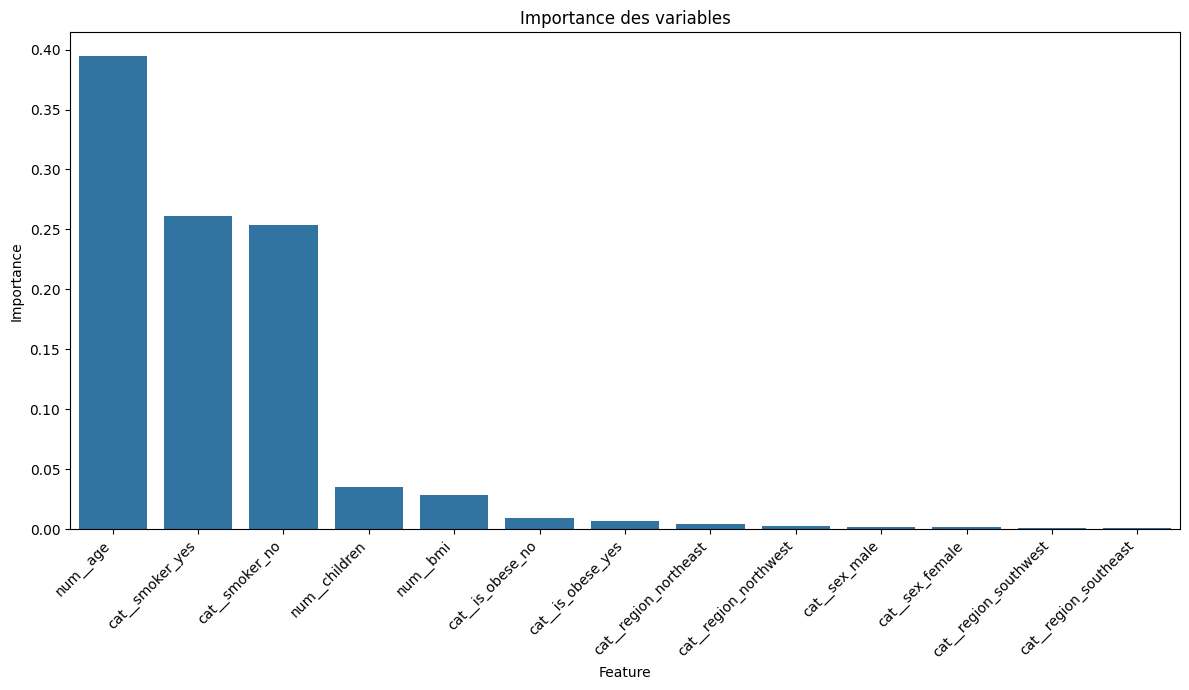

In [76]:
# Plot feature importances
plt.figure(figsize=(12, 7)) # Increased figure size for better vertical display
sns.barplot(x='Feature', y='Importance', data=feature_importance_df)
plt.title('Importance des variables')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

#### ***Sauvegarde de la pipeline***

In [77]:


# Choose a relevant file name
model_filename = 'best_gradient_boost_model.joblib'

# Save the best_pipeline
joblib.dump(best_pipeline, model_filename)

print(f"Le meilleur modèle a été sauvegardé sous le nom: {model_filename}")

Le meilleur modèle a été sauvegardé sous le nom: best_gradient_boost_model.joblib


### **Utilisation de la sauvegarde**

In [78]:

# Définit le nom du fichier où le meilleur modèle a été sauvegardé précédemment
model_filename = 'best_gradient_boost_model.joblib'

# Charge le modèle (pipeline complet) depuis le fichier spécifié en utilisant joblib.load()
loaded_pipeline = joblib.load(model_filename)
# Affiche un message confirmant que le modèle a été chargé avec succès
print(f"Le modèle a été chargé depuis {model_filename}")

# Crée un nouveau DataFrame pour une instance de données 'inconnue' sur laquelle nous voulons faire une prédiction.
# Il est essentiel que les noms et l'ordre des colonnes, ainsi que leurs types de données, correspondent à ceux utilisés lors de l'entraînement du modèle.
new_unseen_data = pd.DataFrame({
    'age': [31],         # Âge de la personne (valeur numérique)
    'sex': ['male'],     # Sexe de la personne (catégorie)
    'bmi': [25],         # Indice de masse corporelle (IMC) (valeur numérique)
    'children': [1],       # Nombre d'enfants (valeur numérique)
    'smoker': ['yes'],      # Indicateur si la personne est fumeuse ou non (catégorie)
    'is_obese': ['yes'],
    'region': ['southwest'] # Région d'habitation de la personne (catégorie)
})

# Utilise le pipeline chargé ('loaded_pipeline') pour prédire les charges pour la nouvelle instance de données.
# La méthode .predict() applique automatiquement toutes les étapes de prétraitement (scaling, encodage) avant la prédiction par le modèle sous-jacent.
predicted_charge_loaded_model = loaded_pipeline.predict(new_unseen_data)

# Affiche le résultat de la prédiction.
# predicted_charge_loaded_model est un tableau NumPy, nous accédons au premier (et unique) élément [0]
# et le formatons pour afficher deux chiffres après la virgule pour plus de clarté.
print(f"Prédiction des charges pour la nouvelle donnée en utilisant le modèle chargé : {predicted_charge_loaded_model[0]:.2f}")

Le modèle a été chargé depuis best_gradient_boost_model.joblib
Prédiction des charges pour la nouvelle donnée en utilisant le modèle chargé : 24296.48


#### **Utilisation du SHAP**

In [85]:
best_model_idx1 = results['MAE_Test'].idxmin()
best_model1 = results.loc[best_model_idx1]
display(best_model1)

,24
Model,SVR
Scaler,MaxAbs
Encoder,OneHot_DropFirst
Best_MAE_CV,0.38378
MAE_Train,0.162344
MAE_Test,0.168021
MSE_Train,0.138405
MSE_Test,0.126895
RMSE_Train,0.372028
RMSE_Test,0.356224


In [86]:
# Nom et paramètres du meilleur modèle
best_model_name1 = model_key = f"{best_model1['Model']}_{best_model1['Scaler']}_{best_model1['Encoder']}"
best_params1 = best_model['Best_Params']

print(f"Meilleur modèle: {best_model_name1}")
print(f"Hyperparamètres optimaux: {best_params1}")

Meilleur modèle: SVR_MaxAbs_OneHot_DropFirst
Hyperparamètres optimaux: {'reg__C': 10, 'reg__epsilon': 0.1, 'reg__kernel': 'rbf'}


In [87]:
#Pipeline du meilleur modèle
best_pipeline1 = best_models_dict[best_model_name1]

print(f"Objet pipeline du meilleur modèle: {best_pipeline1}")

Objet pipeline du meilleur modèle: Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MaxAbsScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('reg', SVR(C=10))])


In [89]:


# 1. Extraire le preprocessor et le modèle de la pipeline
preprocessor = best_pipeline1.named_steps['prepro']
model = best_pipeline1.named_steps['reg']

# 2. Transformer X_test et récupérer les vrais noms des colonnes (ex: sex_male, region_northwest)
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# 3. Convertir en DataFrame pour que le graphique SHAP soit lisible
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

In [96]:
# Utiliser un résumé des données pour servir de référence (accélère le calcul)
# On prend 10 points représentatifs pour la base de comparaison
X_train_summary = shap.kmeans(X_test_df, 10)

# Créer l'explainer
explainer = shap.KernelExplainer(model.predict, X_train_summary)

# Calculer les valeurs SHAP pour un échantillon du test set (ex: 50 individus)
# Ne pas faire sur tout le dataset si tu as des milliers de lignes, ça prendrait trop de temps
shap_values = explainer.shap_values(X_test_df.iloc[:50, :])

  0%|          | 0/50 [00:00<?, ?it/s]

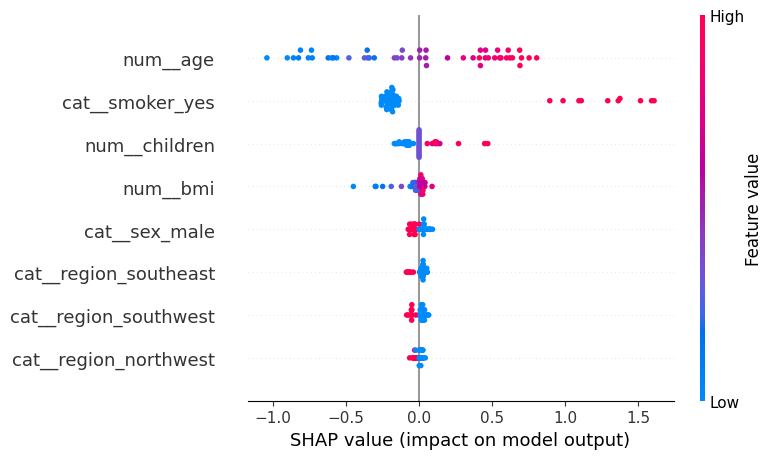

In [97]:
shap.summary_plot(shap_values, X_test_df.iloc[:50, :])

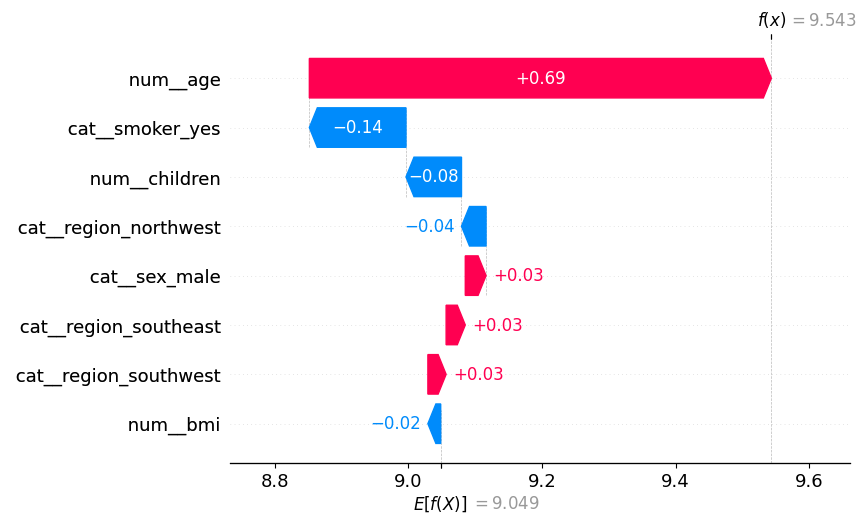

In [98]:
# Expliquer la première prédiction du jeu de test
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[0], X_test_df.iloc[0, :])